In [16]:
from google.colab import files
upload= files.upload()

Saving Q38_driver_ratings.csv to Q38_driver_ratings (3).csv


In [17]:
import pandas as pd
df = pd.read_csv('Q38_driver_ratings.csv')
display(df.head())

,driver_id,driver_experience_years,trip_count,cancellation_rate_percent,distance_travelled_km,passenger_rating
0,DR0001,3.9,1119,12.6,9845.0,4.23
1,DR0002,10.0,1586,18.2,28619.0,4.19
2,DR0003,9.4,2418,5.9,77919.0,4.22
3,DR0004,8.0,2009,17.1,51529.0,3.90
4,DR0005,4.4,1311,8.5,32513.0,3.74


In [18]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   driver_id                  123 non-null    object 
 1   driver_experience_years    123 non-null    float64
 2   trip_count                 123 non-null    int64  
 3   cancellation_rate_percent  122 non-null    float64
 4   distance_travelled_km      122 non-null    float64
 5   passenger_rating           122 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.9+ KB


None

In [19]:
for column in ['cancellation_rate_percent', 'distance_travelled_km', 'passenger_rating']:
  if df[column].isnull().any():
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)
print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
driver_id,0
driver_experience_years,0
trip_count,0
cancellation_rate_percent,0
distance_travelled_km,0
passenger_rating,0


In [20]:
df['trips_per_year'] = df['trip_count'] / df['driver_experience_years']
print("New feature 'trips_per_year' created. Displaying relevant columns:")
display(df[['driver_id', 'passenger_rating', 'cancellation_rate_percent', 'trips_per_year']].head())

New feature 'trips_per_year' created. Displaying relevant columns:


,driver_id,passenger_rating,cancellation_rate_percent,trips_per_year
0,DR0001,4.23,12.6,286.923077
1,DR0002,4.19,18.2,158.600000
2,DR0003,4.22,5.9,257.234043
3,DR0004,3.90,17.1,251.125000
4,DR0005,3.74,8.5,297.954545


In [21]:
df['experience_band'] = pd.cut(
 df['driver_experience_years'],
 bins=[-1, 2, 5, 100],
 labels=['Beginner', 'Intermediate', 'Experienced']
)
print("Average Passenger Rating by Experience Band:")
print(df.groupby('experience_band', observed=True)['passenger_rating'].mean())

Average Passenger Rating by Experience Band:
experience_band
Beginner        3.881176
Intermediate    4.040714
Experienced     4.098846
Name: passenger_rating, dtype: float64


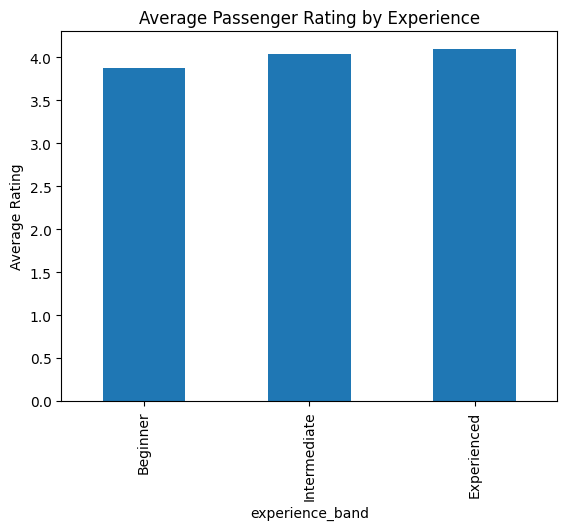

In [28]:
import matplotlib.pyplot as plt
df.groupby('experience_band', observed=True)['passenger_rating'].mean().plot(
  kind='bar', title='Average Passenger Rating by Experience'
)
plt.ylabel('Average Rating')
plt.show()

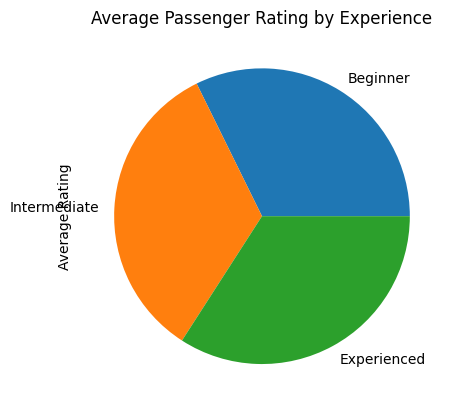

In [26]:
import matplotlib.pyplot as plt
df.groupby('experience_band', observed=True)['passenger_rating'].mean().plot(
  kind='pie', title='Average Passenger Rating by Experience'
)
plt.ylabel('Average Rating')
plt.show()

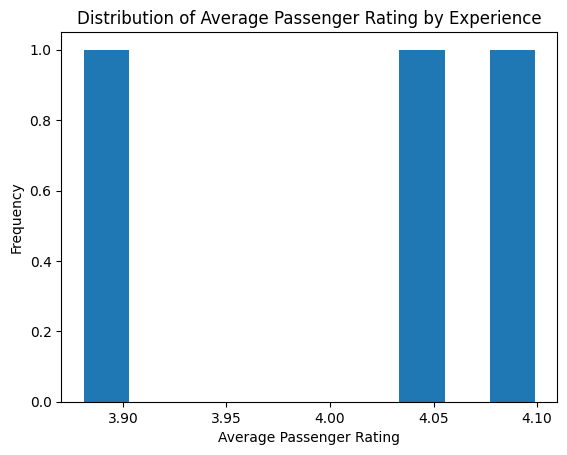

In [32]:
import matplotlib.pyplot as plt
df.groupby('experience_band', observed=True)['passenger_rating'].mean().plot(
  kind='hist', title='Distribution of Average Passenger Rating by Experience'
)
plt.xlabel('Average Passenger Rating')
plt.ylabel('Frequency')
plt.show()

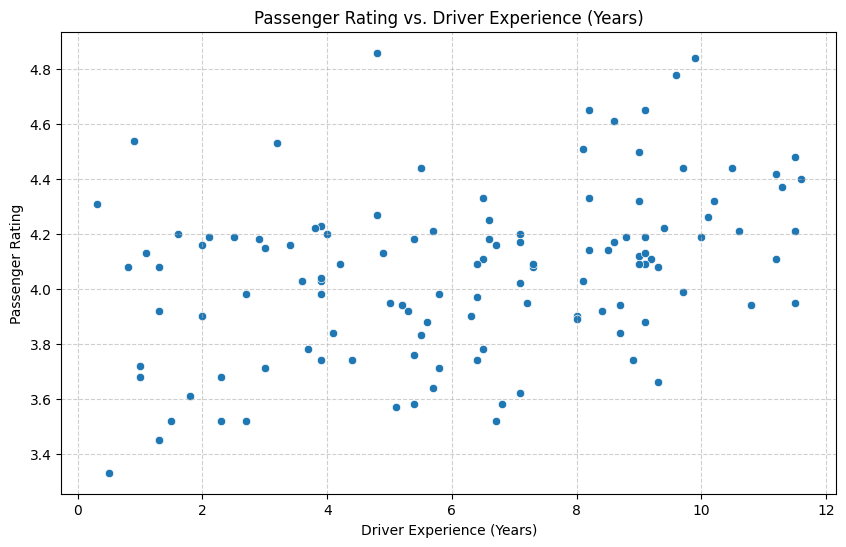

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='driver_experience_years', y='passenger_rating', data=df)
plt.title('Passenger Rating vs. Driver Experience (Years)')
plt.xlabel('Driver Experience (Years)')
plt.ylabel('Passenger Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()